In [3]:
import sys
!{sys.executable} -m pip install python-louvain

  Using cached python-louvain-0.16.tar.gz (204 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9414 sha256=09f9b88ac22f7c8ea0281be18263d4b7b7792b203719c788e3d04aa6e6392d3f
  Stored in directory: c:\users\lenovo\appdata\local\pip\cache\wheels\4d\7c\b6\79b198e4ec43f915fbdf967953d48b89a18893b12aa9df0ae2
Successfully built python-louvain


In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import community as community_louvain

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
club_nodes = pd.read_csv("club_nodes.csv")
club_edges = pd.read_csv("club_edges.csv")

print("Nodes:", club_nodes.shape)
print("Edges:", club_edges.shape)

display(club_nodes.head())
display(club_edges.head())

Nodes: (3606, 15)
Edges: (31272, 10)


,club,country,transfers_out,total_fee_out,transfers_in,total_fee_in,total_transfers,total_fee_involved,degree,in_degree,out_degree,weighted_in_degree,weighted_out_degree,weighted_degree,pagerank
0,Wigan Athletic,England,143.0,153050000.0,155.0,81775000.0,298.0,2.348250e+08,144,75,69,155,143,298,0.001938
1,Molde FK,Norway,16.0,17260000.0,8.0,2000000.0,24.0,1.926000e+07,17,6,11,8,16,24,0.000137
2,FC Girondins Bordeaux,France,256.0,471620000.0,272.0,251180000.0,528.0,7.228000e+08,218,99,119,272,256,528,0.002862
3,Newcastle United,England,274.0,567420000.0,293.0,849790000.0,567.0,1.417210e+09,252,128,124,293,274,567,0.003672
4,Manchester United U18,England,15.0,0.0,0.0,0.0,15.0,0.000000e+00,3,0,3,0,15,15,0.000060


,source_club,target_club,transfer_count,total_transfer_fee,average_transfer_fee,max_transfer_fee,first_season,last_season,source_country,target_country
0,1. FC Brno,SC Heerenveen,1,0.0,0.0,0.0,2009,2009,Czech Republic,Netherlands
1,1. FC Köln,1.FC Heidenheim 1846,1,600000.0,600000.0,600000.0,2015,2015,Germany,Germany
2,1. FC Köln,1.FC Kaiserslautern,2,500000.0,250000.0,500000.0,2014,2015,Germany,Germany
3,1. FC Köln,1.FC Köln II,3,0.0,0.0,0.0,2014,2015,Germany,Germany
4,1. FC Köln,1.FC Nuremberg,5,800000.0,160000.0,500000.0,2009,2019,Germany,Germany


In [3]:
G = nx.Graph()

# Add nodes
for _, row in club_nodes.iterrows():
    G.add_node(
        row["club"],
        country=row["country"],
        pagerank=row["pagerank"],
        degree=row["degree"],
        weighted_degree=row["weighted_degree"]
    )

# Add edges
for _, row in club_edges.iterrows():
    G.add_edge(
        row["source_club"],
        row["target_club"],
        weight=row["transfer_count"],
        total_transfer_fee=row["total_transfer_fee"]
    )

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Network density:", nx.density(G))

Number of nodes: 3606
Number of edges: 22664
Network density: 0.003486868472410369


In [4]:
partition = community_louvain.best_partition(G, weight="weight", random_state=42)

# Add cluster result to club_nodes
club_nodes["louvain_cluster"] = club_nodes["club"].map(partition)

club_nodes.head()

,club,country,transfers_out,total_fee_out,transfers_in,total_fee_in,total_transfers,total_fee_involved,degree,in_degree,out_degree,weighted_in_degree,weighted_out_degree,weighted_degree,pagerank,louvain_cluster
0,Wigan Athletic,England,143.0,153050000.0,155.0,81775000.0,298.0,2.348250e+08,144,75,69,155,143,298,0.001938,0
1,Molde FK,Norway,16.0,17260000.0,8.0,2000000.0,24.0,1.926000e+07,17,6,11,8,16,24,0.000137,0
2,FC Girondins Bordeaux,France,256.0,471620000.0,272.0,251180000.0,528.0,7.228000e+08,218,99,119,272,256,528,0.002862,1
3,Newcastle United,England,274.0,567420000.0,293.0,849790000.0,567.0,1.417210e+09,252,128,124,293,274,567,0.003672,0
4,Manchester United U18,England,15.0,0.0,0.0,0.0,15.0,0.000000e+00,3,0,3,0,15,15,0.000060,0


In [5]:
club_nodes["louvain_cluster"].nunique()

7

In [6]:
cluster_counts = club_nodes["louvain_cluster"].value_counts().sort_index()
cluster_counts

louvain_cluster
0    412
1    427
2    826
3    297
4    884
5    464
6    296
Name: count, dtype: int64

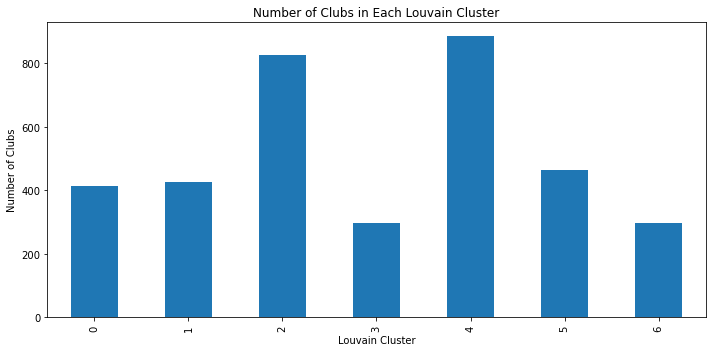

In [7]:
plt.figure(figsize=(10, 5))
cluster_counts.plot(kind="bar")
plt.title("Number of Clubs in Each Louvain Cluster")
plt.xlabel("Louvain Cluster")
plt.ylabel("Number of Clubs")
plt.tight_layout()
plt.show()

In [8]:
for cluster_id in sorted(club_nodes["louvain_cluster"].unique()):
    print(f"\nCluster {cluster_id}")
    display(
        club_nodes[club_nodes["louvain_cluster"] == cluster_id]
        .sort_values("pagerank", ascending=False)
        [["club", "country", "pagerank", "degree", "weighted_degree"]]
        .head(10)
    )


Cluster 0


,club,country,pagerank,degree,weighted_degree
37,Chelsea FC,England,0.006258,340,1143
27,Manchester City,England,0.004848,308,896
5,Tottenham Hotspur,England,0.004334,238,723
83,Sunderland AFC,England,0.003893,248,611
55,West Ham United,England,0.003855,271,606
183,Crystal Palace,England,0.003837,220,466
25,Liverpool FC,England,0.003722,255,687
3,Newcastle United,England,0.003672,252,567
62,Aston Villa,England,0.003657,228,597
117,Stoke City,England,0.003640,217,509



Cluster 1


,club,country,pagerank,degree,weighted_degree
179,AS Monaco,France,0.005142,308,918
320,LOSC Lille,France,0.003847,234,595
246,Stade Rennais FC,France,0.003543,251,656
135,Olympique Marseille,France,0.003455,239,604
181,AS Saint-Étienne,France,0.003178,246,576
2,FC Girondins Bordeaux,France,0.002862,218,528
485,OGC Nice,France,0.002830,224,535
379,Montpellier HSC,France,0.002617,185,361
289,Paris Saint-Germain,France,0.002560,191,563
517,FC Metz,France,0.002444,174,313



Cluster 2


...

,club,country,pagerank,degree,weighted_degree
174,SC Braga,Portugal,0.008809,358,1116
129,SL Benfica,Portugal,0.008656,436,1285
262,FC Porto,Portugal,0.007986,347,1201
185,Sporting CP,Portugal,0.007218,424,1078
536,Vitória Setúbal FC,Portugal,0.007159,328,707
505,FC Paços de Ferreira,Portugal,0.006902,313,704
422,Rio Ave FC,Portugal,0.005762,274,732
217,Vitória Guimarães SC,Portugal,0.005687,314,749
456,CS Marítimo,Portugal,0.005671,290,572
595,Boavista FC,Portugal,0.005468,262,460



Cluster 5


,club,country,pagerank,degree,weighted_degree
428,ADO Den Haag,Netherlands,0.003467,223,527
394,SC Heerenveen,Netherlands,0.003289,234,534
327,Feyenoord Rotterdam,Netherlands,0.003257,190,564
283,Vitesse Arnhem,Netherlands,0.003189,206,525
209,Twente Enschede FC,Netherlands,0.003159,227,537
336,Willem II Tilburg,Netherlands,0.003098,187,494
451,FC Groningen,Netherlands,0.002963,210,478
299,FC Utrecht,Netherlands,0.002890,182,496
374,Fortuna Sittard,Netherlands,0.002817,168,251
225,PSV Eindhoven,Netherlands,0.002816,192,530



Cluster 6


,club,country,pagerank,degree,weighted_degree
284,TSG 1899 Hoffenheim,Germany,0.003791,261,662
291,VfL Wolfsburg,Germany,0.003778,242,643
293,FC Schalke 04,Germany,0.003437,215,621
550,1.FSV Mainz 05,Germany,0.003337,206,536
355,Eintracht Frankfurt,Germany,0.003326,231,552
172,Bayer 04 Leverkusen,Germany,0.003160,206,543
36,SV Werder Bremen,Germany,0.002926,224,523
458,FC Augsburg,Germany,0.002776,170,445
195,VfB Stuttgart,Germany,0.002768,189,471
347,SC Freiburg,Germany,0.002705,180,431


In [9]:
cluster_country_summary = (
    club_nodes.groupby(["louvain_cluster", "country"])
    .size()
    .reset_index(name="club_count")
    .sort_values(["louvain_cluster", "club_count"], ascending=[True, False])
)

cluster_country_summary.head(30)

,louvain_cluster,country,club_count
11,0,England,269
29,0,Scotland,21
18,0,Ireland,16
38,0,United States,11
2,0,Belgium,8
36,0,Turkey,8
39,0,Wales,7
4,0,China,5
26,0,Poland,5
8,0,Denmark,4


In [10]:
top_countries_by_cluster = (
    cluster_country_summary
    .groupby("louvain_cluster")
    .head(5)
)

display(top_countries_by_cluster)

,louvain_cluster,country,club_count
11,0,England,269
29,0,Scotland,21
18,0,Ireland,16
38,0,United States,11
2,0,Belgium,8
63,1,France,216
46,1,Belgium,19
103,1,Switzerland,9
105,1,Turkey,9
91,1,Qatar,7


In [11]:
top_countries_by_cluster.to_csv("top_countries_by_louvain_cluster.csv", index=False)

In [12]:
club_nodes["louvain_cluster"].value_counts()

louvain_cluster
4    884
2    826
5    464
1    427
0    412
3    297
6    296
Name: count, dtype: int64

In [13]:
def get_cluster_label(cluster_id):
    countries = (
        club_nodes[club_nodes["louvain_cluster"] == cluster_id]["country"]
        .value_counts()
        .head(2)
        .index
        .tolist()
    )
    return " / ".join(countries)

cluster_labels = {
    cluster_id: get_cluster_label(cluster_id)
    for cluster_id in sorted(club_nodes["louvain_cluster"].unique())
}

cluster_labels

{0: 'England / Scotland',
 1: 'France / Belgium',
 2: 'Italy / Romania',
 3: 'Spain / Argentina',
 4: 'Portugal / Brazil',
 5: 'Netherlands / Belgium',
 6: 'Germany / Austria'}

In [14]:
club_nodes["louvain_cluster_label"] = club_nodes["louvain_cluster"].map(cluster_labels)

club_nodes[["club", "country", "louvain_cluster", "louvain_cluster_label"]].head()

,club,country,louvain_cluster,louvain_cluster_label
0,Wigan Athletic,England,0,England / Scotland
1,Molde FK,Norway,0,England / Scotland
2,FC Girondins Bordeaux,France,1,France / Belgium
3,Newcastle United,England,0,England / Scotland
4,Manchester United U18,England,0,England / Scotland


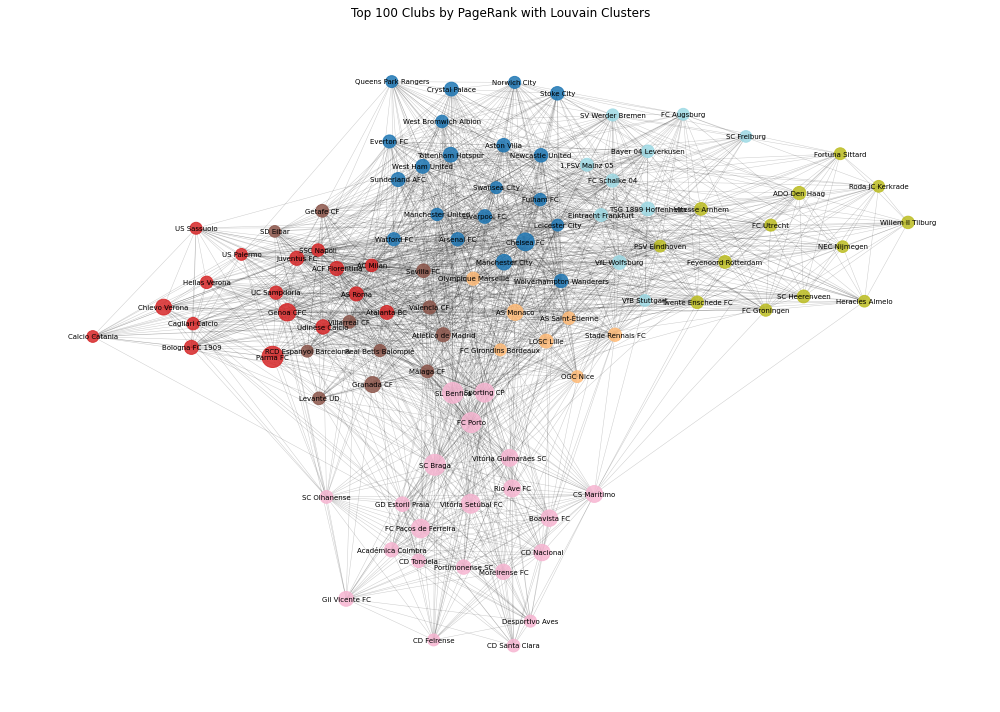

In [15]:
top_clubs = club_nodes.sort_values("pagerank", ascending=False).head(100)["club"].tolist()

G_top = G.subgraph(top_clubs).copy()

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(G_top, seed=42, k=0.5)

node_colors = [
    club_nodes.set_index("club").loc[node, "louvain_cluster"]
    for node in G_top.nodes()
]

node_sizes = [
    club_nodes.set_index("club").loc[node, "pagerank"] * 50000
    for node in G_top.nodes()
]

nx.draw_networkx_nodes(
    G_top,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.tab20,
    alpha=0.85
)

nx.draw_networkx_edges(
    G_top,
    pos,
    alpha=0.2,
    width=0.5
)

nx.draw_networkx_labels(
    G_top,
    pos,
    font_size=7
)

plt.title("Top 100 Clubs by PageRank with Louvain Clusters")
plt.axis("off")
plt.tight_layout()
plt.show()

In [17]:
club_nodes.to_csv("club_nodes_with_clusters.csv", index=False)

print("Saved to club_nodes_with_clusters.csv")

Saved to club_nodes_with_clusters.csv
